#Task 1 Жай сызықтық регрессияны қолмен есептеу (опциональная)


Есептелген коэффициенттер:
beta_1 (еңіс): 0.80
beta_0 (бос мүше): 1.80


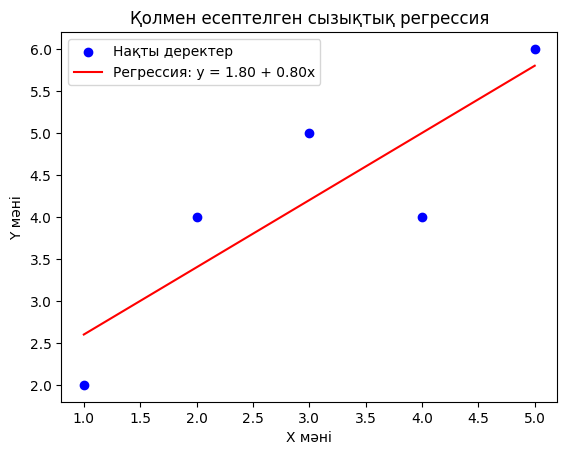

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Деректер
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

# 2. Орташа мәндерді табу (x_mean, y_mean)
x_mean = np.mean(x)
y_mean = np.mean(y)

# 3. Коэффициенттерді есептеу (формула бойынша)
# beta_1 = sum((x - x_mean) * (y - y_mean)) / sum((x - x_mean)**2)
numerator = np.sum((x - x_mean) * (y - y_mean))  # Алымы
denominator = np.sum((x - x_mean)**2)            # Бөлімі

beta_1 = numerator / denominator
beta_0 = y_mean - (beta_1 * x_mean)

print(f"Есептелген коэффициенттер:")
print(f"beta_1 (еңіс): {beta_1:.2f}")
print(f"beta_0 (бос мүше): {beta_0:.2f}")

# 4. Регрессия теңдеуі бойынша болжам жасау
# y = 50.00 + 50.50 * x
y_pred = beta_0 + beta_1 * x

# 5. Нәтижені визуализациялау
plt.scatter(x, y, color='blue', label='Нақты деректер')
plt.plot(x, y_pred, color='red', label=f'Регрессия: y = {beta_0:.2f} + {beta_1:.2f}x')
plt.xlabel('X мәні')
plt.ylabel('Y мәні')
plt.legend()
plt.title('Қолмен есептелген сызықтық регрессия')
plt.show()

#Task 2 Scikit-learn арқылы Linear Regression

Теңдеу: y = 3.00 + 1.10 * x
60 үшін болжам мән: 69.00


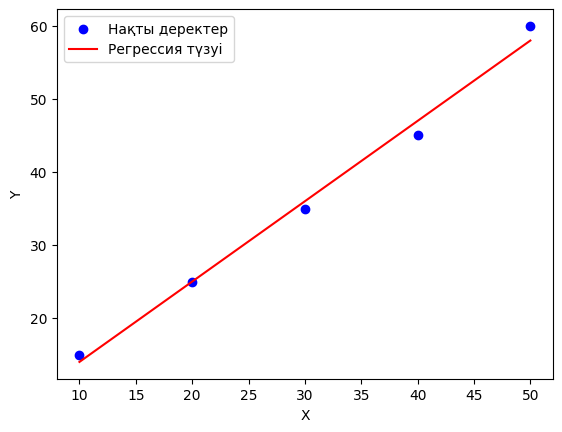

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


X = np.array([[10], [20], [30], [40], [50]])
y = np.array([15, 25, 35, 45, 60])

# 2. Модельді құру және оқыту
model = LinearRegression()
model.fit(X, y)

# 3. Коэффициенттерді алу
beta_0 = model.intercept_  # Бос мүше
beta_1 = model.coef_[0]    # Еңіс (slope)

print(f"Теңдеу: y = {beta_0:.2f} + {beta_1:.2f} * x")

# 4. Болжам жасау
x_new = np.array([[60]])
y_pred = model.predict(x_new)
print(f"60 үшін болжам мән: {y_pred[0]:.2f}")

# 5. Графикті шығару
plt.scatter(X, y, color='blue', label='Нақты деректер')
plt.plot(X, model.predict(X), color='red', label='Регрессия түзуі')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

#Task 3 Қате есептеу (MSE)

In [ ]:
# MSE есептеу
y_pred = model.predict(X)
mse = np.mean((y - y_pred)**2)
print(f"Қолмен есептелген MSE: {mse:.2f}")

Қолмен есептелген MSE: 2.00


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X)
mse_sklearn = mean_squared_error(y, y_pred)
print(f"Sklearn арқылы MSE: {mse_sklearn:.2f}")

Sklearn арқылы MSE: 2.00


#Task 4. Train / Test бөлу

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Деректерді 80/20 қатынасында араластырып бөлу
# random_state=42 нәтиженің тұрақты болуы үшін керек
X = np.array([[10], [20], [30], [40], [50], [60], [70], [80]])
y = np.array([15, 23, 38, 44, 55, 68, 72, 85])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Үйрету
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Болжамдар жасау
y_train_pred = model.predict(X_train) # Үйрету деректері бойынша болжам
y_test_pred = model.predict(X_test)   # Тексеру деректері бойынша болжам

# 5. MSE-лерді есептеу
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Train MSE: 2.50
Test MSE: 10.31


#Task 4. Train / Test бөлу

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge

# 1. Деректерді дайындау
X = np.array([[10], [20], [30], [40], [50], [60], [70], [80]])
y = np.array([15, 23, 38, 44, 55, 68, 72, 85])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Жай Сызықтық регрессия (OLS)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 3. Ridge регрессиясы (alpha = 0.1)
ridge_model1 = Ridge(alpha=0.1)
ridge_model1.fit(X_train, y_train)

# 4. Ridge регрессиясы (alpha = 10)
ridge_model2 = Ridge(alpha=10)
ridge_model2.fit(X_train, y_train)

# 5. Болжамдар жасау
y_pred_lr = lr_model.predict(X_test)
y_pred_ridge1 = ridge_model1.predict(X_test)
y_pred_ridge2 = ridge_model2.predict(X_test)

# 6. Салыстыру
print(f"Жай регрессия MSE: {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"Ridge регрессия (0.1) MSE: {mean_squared_error(y_test, y_pred_ridge1):.2f}")
print(f"Ridge регрессия (10) MSE: {mean_squared_error(y_test, y_pred_ridge2):.2f}")

print(f"Жай регрессия коэффициенті: {lr_model.coef_[0]:.4f}")
print(f"Ridge (0.1) коэффициенті: {ridge_model1.coef_[0]:.4f}")
print(f"Ridge (10) коэффициенті: {ridge_model1.coef_[0]:.4f}")

Жай регрессия MSE: 10.31
Ridge регрессия (0.1) MSE: 10.31
Ridge регрессия (10) MSE: 10.66
Жай регрессия коэффициенті: 0.9660
Ridge (0.1) коэффициенті: 0.9660
Ridge (10) коэффициенті: 0.9660


#Task 6. Alpha әсерін зерттеу (опциональная)

Alpha: 0.001 | Coef: 0.9952 | MSE: 3.9881
Alpha: 0.01 | Coef: 0.9952 | MSE: 3.9881
Alpha: 0.1 | Coef: 0.9952 | MSE: 3.9881
Alpha: 1 | Coef: 0.9950 | MSE: 3.9881
Alpha: 10 | Coef: 0.9929 | MSE: 3.9910
Alpha: 100 | Coef: 0.9721 | MSE: 4.2693


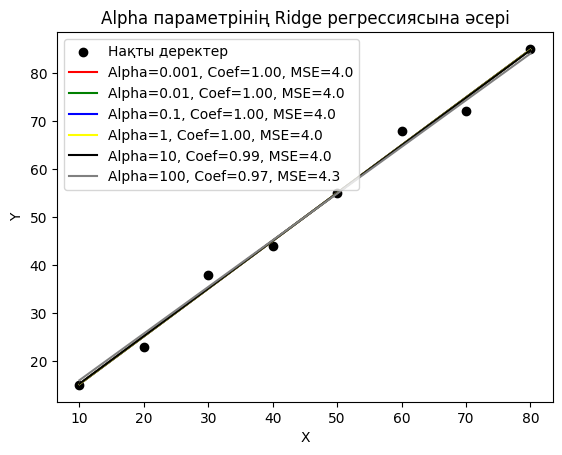

In [ ]:
# Зерттелетін alpha мәндері
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
colors = ['red', 'green', 'blue', 'yellow', 'black', 'grey']

plt.scatter(X, y, color='black', label='Нақты деректер')

for a, c in zip(alphas, colors):
    # Модельді құру және оқыту
    ridge = Ridge(alpha=a)
    ridge.fit(X, y)

    # Болжам жасау
    y_pred = ridge.predict(X)

    # Коэффициент және MSE
    mse = mean_squared_error(y, y_pred)
    coef = ridge.coef_[0]

    # Графигін салу
    plt.plot(X, y_pred, color=c, label=f'Alpha={a}, Coef={coef:.2f}, MSE={mse:.1f}')

    print(f"Alpha: {a} | Coef: {coef:.4f} | MSE: {mse:.4f}")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Alpha параметрінің Ridge регрессиясына әсері')
plt.show()